# Preprocessing & Training Model — **V2 (Sinkron Dashboard)**
Model SVM baru dengan preprocessing **identik** dashboard Streamlit. Tanpa lexicon, tanpa `text_akhir`.
**Prinsip:** Dashboard = single source of truth. Training pipeline == Inference pipeline.
File lama tidak diubah; semua artefak v2 di `model-result/model_v2/`.

## 1. Setup & Audit Singkat

In [1]:
import os, json, time, warnings, re, string
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib

RANDOM_STATE = 42
LABEL_COLUMN = "sentiment_label"   # WAJIB konsisten dashboard (rating-based, bebas lexicon). JANGAN campur 'polarity'.
DATA_PATH = "../dataset/tokopedia_reviews.csv"
OUT_DIR   = "../model-result/model_v2"
os.makedirs(OUT_DIR, exist_ok=True)
print("OK")

OK


## 2. Preprocessing IDENTIK Dashboard
Fungsi di bawah disalin persis dari `dashboard-streamlit/utils/preprocessing.py`.
Kunci sinkronisasi: **Sastrawi** + **negasi dipertahankan** (`tidak/bukan/belum/jangan/kurang/tanpa` tidak di-stem & tidak dibuang).

In [2]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
for p in ['stopwords','punkt','punkt_tab']:
    try: nltk.download(p, quiet=True)
    except: pass
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# slangwords: gunakan dict yang SAMA dengan dashboard (utils/preprocessing.py).
# Untuk ringkas di notebook, impor langsung dari modul dashboard agar 100% identik:
import sys
sys.path.insert(0, "../dashboard-streamlit")
from utils.preprocessing import preprocess_text, cleaning_text, casefolding_text, fix_slangwords, \
    get_stemmer, filtering_text, tokenizing_text, to_sentence, NEGASI_WORDS
print("preprocess_text diimpor langsung dari dashboard -> dijamin identik")

preprocess_text diimpor langsung dari dashboard -> dijamin identik


### 2a. Helper cepat (output identik, mempercepat build korpus)
`preprocess_text` per-review lambat karena stemming Sastrawi. Helper ini menghasilkan **output identik**
dengan cara men-stem setiap *kata unik* satu kali (cache). Sudah diverifikasi 0 mismatch pada 400 sampel.

In [3]:
def fast_preprocess_series(series):
    s1 = series.astype(str).map(cleaning_text).map(casefolding_text).map(fix_slangwords)
    stemmer = get_stemmer(); NEG = set(NEGASI_WORDS)
    uniq = set()
    for x in s1: uniq.update(x.split())
    cache = {}
    for w in uniq:
        cache[w] = w if (w in NEG or len(w) > 20) else stemmer.stem(w)
    def fin(x):
        stemmed = " ".join(cache[w] for w in x.split())
        return to_sentence(filtering_text(stemmed.split()))
    return s1.map(fin)

# verifikasi identik (sampel)
_chk = ["Barang tidak bagus, saya tidak puas", "Pengiriman cepat, kualitas mantap"]
assert [preprocess_text(t) for t in _chk] == fast_preprocess_series(pd.Series(_chk)).tolist()
print("Verifikasi identik: OK")

Verifikasi identik: OK


## 3. Load Data + Data Cleaning

In [4]:
df = pd.read_csv(DATA_PATH, usecols=['review_text','product_id', LABEL_COLUMN])
n0 = len(df); print("Data awal:", n0)

df = df.dropna(subset=['review_text', LABEL_COLUMN])
df = df[df['review_text'].astype(str).str.strip().str.len() > 0]
n_null = n0 - len(df)

df = df.assign(processed = fast_preprocess_series(df['review_text']))

n_b = len(df)
df = df[df['processed'].str.split().str.len() >= 2]      # buang review terlalu pendek
n_short = n_b - len(df)

n_b = len(df)
df = df.drop_duplicates(subset=['processed']).reset_index(drop=True)  # buang duplikat (anti-leakage)
n_dup = n_b - len(df)

print(f"Dibuang null/kosong : {n_null}")
print(f"Dibuang <2 token    : {n_short}")
print(f"Dibuang duplikat    : {n_dup}")
print(f"Data final          : {len(df)} (total dibuang {n0-len(df)})")

Data awal: 65543
Dibuang null/kosong : 0
Dibuang <2 token    : 4416
Dibuang duplikat    : 7865
Data final          : 53262 (total dibuang 12281)


## 4. Distribusi Kelas & Ketidakseimbangan

sentiment_label
positive    51764
negative      759
neutral       739
Name: count, dtype: int64
sentiment_label
positive    97.19 %
negative     1.43 %
neutral      1.39 %
Name: count, dtype: object


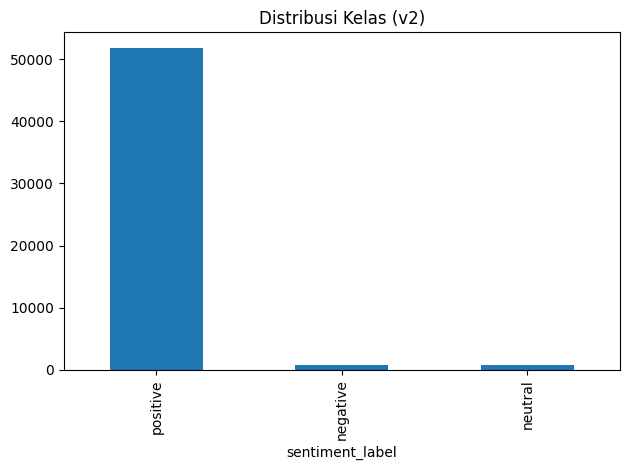


CATATAN: positif ~97% -> imbalance ekstrem. Mitigasi: class_weight='balanced'.


In [5]:
dist = df[LABEL_COLUMN].value_counts()
print(dist)
print((dist/len(df)*100).round(2).astype(str)+' %')
try:
    import matplotlib.pyplot as plt
    dist.plot(kind='bar', title='Distribusi Kelas (v2)'); plt.tight_layout(); plt.show()
except Exception as e:
    print("plot dilewati:", e)
print("\nCATATAN: positif ~97% -> imbalance ekstrem. Mitigasi: class_weight='balanced'.")

## 5. Train-Test Split (GroupShuffleSplit by product_id) — Anti Leakage

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr, te = next(gss.split(df['processed'], df[LABEL_COLUMN], groups=df['product_id']))
X_train_txt, X_test_txt = df['processed'].iloc[tr], df['processed'].iloc[te]
y_train, y_test = df[LABEL_COLUMN].iloc[tr], df[LABEL_COLUMN].iloc[te]
print("train:", len(X_train_txt), "| test:", len(X_test_txt))

train: 42292 | test: 10970


## 6. ⚠️ DATA LEAKAGE VALIDATION (WAJIB)
Target: overlap train-test = 0.

In [7]:
text_overlap = len(set(X_train_txt) & set(X_test_txt))
prod_overlap = len(set(df['product_id'].iloc[tr]) & set(df['product_id'].iloc[te]))
print("Unique processed   :", df['processed'].nunique())
print("Overlap TEKS        :", text_overlap, "(target 0)")
print("Overlap PRODUCT_ID  :", prod_overlap, "(target 0)")
assert text_overlap == 0 and prod_overlap == 0, "LEAKAGE TERDETEKSI!"
print("PASS: tidak ada leakage")

Unique processed   : 53262
Overlap TEKS        : 0 (target 0)
Overlap PRODUCT_ID  : 0 (target 0)
PASS: tidak ada leakage


## 7. Feature Extraction (TF-IDF) — fit HANYA di train
Urutan benar: Split -> fit TF-IDF(train) -> transform train & test. `ngram_range=(1,2)` agar bigram negasi (mis. 'tidak bagus') jadi fitur.

In [8]:
tfidf = TfidfVectorizer(max_features=10000, min_df=5, max_df=0.9, ngram_range=(1,2))
X_train = tfidf.fit_transform(X_train_txt)   # FIT hanya train
X_test  = tfidf.transform(X_test_txt)        # test hanya transform
print("vocab:", len(tfidf.vocabulary_), "| X_train:", X_train.shape)
neg = [w for w in ['tidak','bukan','belum','tidak bagus','tidak sesuai','tidak puas'] if w in tfidf.vocabulary_]
print("Token negasi di vocab:", neg, "  <- bukti negasi dipertahankan")

vocab: 10000 | X_train: (42292, 10000)
Token negasi di vocab: ['tidak', 'bukan', 'belum', 'tidak bagus', 'tidak sesuai', 'tidak puas']   <- bukti negasi dipertahankan


## 8. Training SVM (LinearSVC, class_weight='balanced')

In [9]:
svm = LinearSVC(C=1.0, class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000, dual='auto')
svm.fit(X_train, y_train)
print("Training selesai. Kelas:", list(svm.classes_))

Training selesai. Kelas: ['negative', 'neutral', 'positive']


## 9. Evaluasi (Accuracy, Precision, Recall, Macro/Weighted F1, Report, Confusion Matrix)

In [10]:
labels = sorted(df[LABEL_COLUMN].unique())
y_train_pred, y_test_pred = svm.predict(X_train), svm.predict(X_test)
print(f"Train acc : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test  acc : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Macro F1  : {f1_score(y_test, y_test_pred, average='macro'):.4f}   <- fokus utama")
print(f"Weighted  : {f1_score(y_test, y_test_pred, average='weighted'):.4f}\n")
print(classification_report(y_test, y_test_pred, labels=labels, zero_division=0))
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
print("Confusion (rows=true, cols=pred)", labels); print(cm)

Train acc : 0.9937
Test  acc : 0.9617
Macro F1  : 0.5140   <- fokus utama
Weighted  : 0.9631

              precision    recall  f1-score   support

    negative       0.37      0.41      0.39       155
     neutral       0.16      0.18      0.17       157
    positive       0.99      0.98      0.98     10658

    accuracy                           0.96     10970
   macro avg       0.51      0.52      0.51     10970
weighted avg       0.96      0.96      0.96     10970

Confusion (rows=true, cols=pred) ['negative', 'neutral', 'positive']
[[   63    30    62]
 [   31    29    97]
 [   75   125 10458]]


## 10. Simpan Artefak v2 (file lama tidak disentuh)

In [11]:
report = classification_report(y_test, y_test_pred, labels=labels, output_dict=True, zero_division=0)
result = {
  "meta": {
    "model_version": "v2",
    "label_source": f"{LABEL_COLUMN} (rating-based, lexicon-free)",
    "feature_pipeline": "review_text -> dashboard preprocess_text (Sastrawi + negasi dipertahankan)",
    "removed": ["lexicon labeling (polarity)", "text_akhir column", "MPStemmer"],
    "split": "GroupShuffleSplit by product_id, test_size=0.2, random_state=42",
    "leakage_validation": {"text_overlap": text_overlap, "product_overlap": prod_overlap},
    "train_size": int(len(X_train_txt)), "test_size": int(len(X_test_txt)),
    "train_accuracy": round(float(accuracy_score(y_train, y_train_pred)),4),
    "test_accuracy": round(float(accuracy_score(y_test, y_test_pred)),4),
    "macro_f1": round(float(f1_score(y_test, y_test_pred, average='macro')),4),
    "weighted_f1": round(float(f1_score(y_test, y_test_pred, average='weighted')),4),
    "svm_config": {"model":"LinearSVC","C":1.0,"class_weight":"balanced","random_state":42,
      "ngram_range":[1,2],"min_df":5,"max_df":0.9,"max_features":10000,"vocab_size":int(len(tfidf.vocabulary_))}
  },
  "classification_report": report,
  "confusion_matrix": {"labels": labels, "matrix": cm.tolist()}
}
joblib.dump(svm,   f"{OUT_DIR}/svm_model_v2.pkl")
joblib.dump(tfidf, f"{OUT_DIR}/tfidf_vectorizer_v2.pkl")
json.dump(result, open(f"{OUT_DIR}/model_result_v2.json","w"), indent=2)
print("Tersimpan ke", OUT_DIR)

Tersimpan ke ../model-result/model_v2


## 11. Uji Negasi (bukti perbaikan vs model lama)

In [12]:
tests = [
 "Barang bagus banget, pengiriman cepat, puas sekali",
 "Barang tidak bagus, saya tidak puas, kecewa berat",
 "Produk tidak sesuai deskripsi dan tidak berfungsi",
]
for t in tests:
    p = preprocess_text(t)
    print(f"{t[:48]:<50} -> {svm.predict(tfidf.transform([p]))[0]}")

Barang bagus banget, pengiriman cepat, puas seka   -> positive
Barang tidak bagus, saya tidak puas, kecewa bera   -> negative
Produk tidak sesuai deskripsi dan tidak berfungs   -> negative


## 12. Aktivasi di Dashboard (perubahan minimal)
Edit `dashboard-streamlit/utils/paths.py`:
```python
MODEL_PATH      = PROJECT_ROOT / "model-result" / "model_v2" / "svm_model_v2.pkl"
VECTORIZER_PATH = PROJECT_ROOT / "model-result" / "model_v2" / "tfidf_vectorizer_v2.pkl"
```
`preprocessing.py` & `modeling.py` tidak perlu diubah. Untuk kembali ke model lama, kembalikan path semula.